In [ ]:
import numpy as np
import torch
import torchvision.models
import torch.nn as nn
import pandas as pd
import time
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from models.utils import set_seed, train, evaluate_model, plot_training_history, get_loaders
from models.baseline_cnn import BaselineCNN
from models.alexnet import ModifiedAlexNet

from hyperparameter_plots import summarize_results, print_summary_table, plot_loss_comparison, plot_accuracy_comparison
from utils import save_results

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: mps


In [91]:
DATA_DIR = Path("../data")

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

In [105]:
LEARNING_RATES = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
SEEDS = [0, 1, 2]
BATCH_SIZE = 256

In [109]:
def create_baseline_model():
    model = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], 
                        kernel_sizes = [3, 3, 3], fc_layers = [128, 64], num_classes = 10)
    return model

def create_resnet_model():
    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    model = model.to(device)
    return model

def create_alexnet_model():
    model = ModifiedAlexNet(num_classes=10).to(device)
    return model

def test_learning_rate(model, train_loader, valid_loader, test_loader, learning_rates,
        seeds, scheduler=None, device=None, num_epochs=20):
    
    results = {}
    for lr in learning_rates:
        results[lr] = {}
        for seed in seeds:
            print(f"\nLEARNING RATE={lr} | SEED={seed}")
            set_seed(seed)

            model_instance = model()
            criterion = torch.nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model_instance.parameters(), lr=lr)

            print("------------------------------------------------------")


            history = train(model_instance, train_loader, valid_loader, criterion, optimizer,
                scheduler=scheduler, device=device, num_epochs=num_epochs, verbose=True, verbose_interval=int(num_epochs/10))
            
            
            validation_accuracy = history['valid_acc'][-1]
            validation_loss = history['valid_loss'][-1]
            test_accuracy, test_loss = evaluate_model(model_instance, test_loader, criterion, device)

            results[lr][seed] = {
                "history": history,
                "valid_acc": validation_accuracy,
                "valid_loss": validation_loss,
                "test_acc": test_accuracy,
                "test_loss": test_loss
            }

            print("------------------------------------------------------")

            print(f"VALIDATION ACCURACY: {validation_accuracy:.4f} | TEST ACCURACY: {test_accuracy:.4f}")

            print("------------------------------------------------------")

    return results

In [110]:
train_loader, valid_loader, test_loader = get_loaders(train_dir=TRAIN_DIR, valid_dir=VALID_DIR,
                                                      test_dir=TEST_DIR, image_size=32, batch_size=BATCH_SIZE)

## Learning rates experiments

In [111]:
baseline_results = test_learning_rate(model=create_baseline_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, learning_rates=LEARNING_RATES, seeds=SEEDS, num_epochs=20, device=device)


LEARNING RATE=0.01 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.3166 | Valid Loss: 1.3109 | Valid Acc: 0.5260
Epoch 4/20 | Train Loss: 1.0511 | Valid Loss: 1.1712 | Valid Acc: 0.5763
Epoch 6/20 | Train Loss: 0.8686 | Valid Loss: 1.0024 | Valid Acc: 0.6477
Epoch 8/20 | Train Loss: 0.7296 | Valid Loss: 1.0960 | Valid Acc: 0.6244
Epoch 10/20 | Train Loss: 0.5964 | Valid Loss: 0.9929 | Valid Acc: 0.6689
Epoch 12/20 | Train Loss: 0.4961 | Valid Loss: 1.0151 | Valid Acc: 0.6718
Epoch 14/20 | Train Loss: 0.3904 | Valid Loss: 1.1447 | Valid Acc: 0.6612
Epoch 16/20 | Train Loss: 0.3210 | Valid Loss: 1.2102 | Valid Acc: 0.6761
Epoch 18/20 | Train Loss: 0.2573 | Valid Loss: 1.4335 | Valid Acc: 0.6480
Epoch 20/20 | Train Loss: 0.2229 | Valid Loss: 1.4670 | Valid Acc: 0.6641
Best validation accuracy: 0.6761
------------------------------------------------------
VALIDATION ACCURACY: 0.6641 | TEST ACCURACY: 0.6616
----------------------------------------

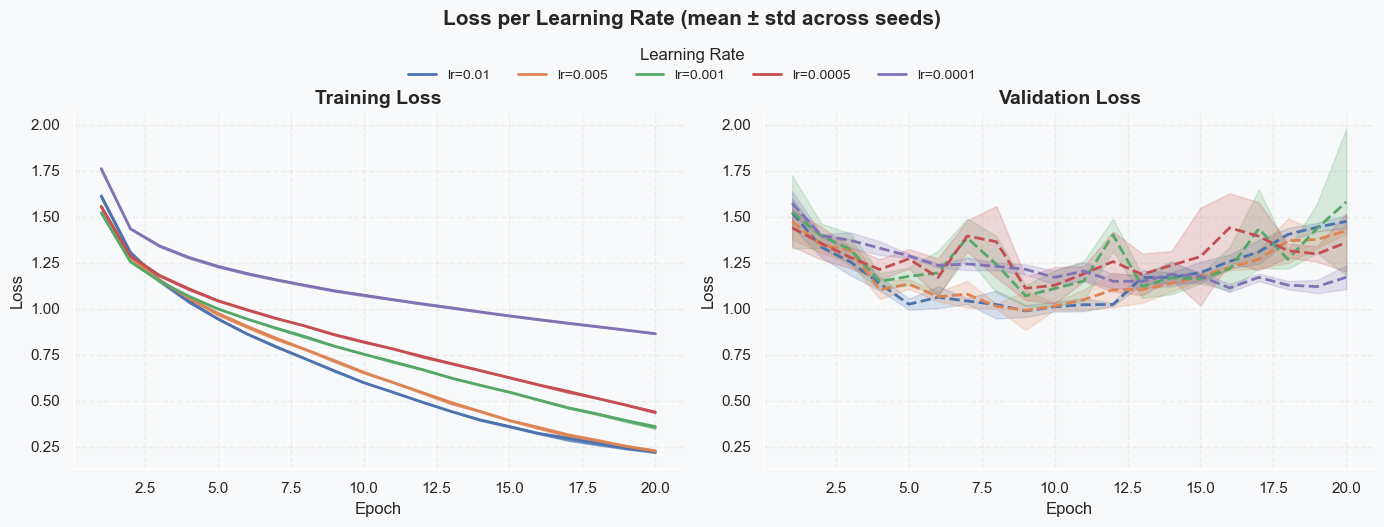

In [201]:
plot_loss_comparison(baseline_results, param_name="Learning Rate", param_name_short = 'lr')

In [156]:
for param, seed_dict in baseline_results.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"lr={param} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

lr=0.01 | seeds=3 | max std=0.011411
lr=0.005 | seeds=3 | max std=0.009002
lr=0.001 | seeds=3 | max std=0.009218
lr=0.0005 | seeds=3 | max std=0.007536
lr=0.0001 | seeds=3 | max std=0.006289


In [198]:
df = summarize_results(baseline_results)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.0100,0.662652,0.007941,1.473861,0.034226,0.660130,0.005960,1.489238,0.028669
1,Model,0.0050,0.664219,0.004882,1.423667,0.015430,0.663311,0.004820,1.432439,0.016287
2,Model,0.0010,0.607081,0.050102,1.579780,0.398951,0.605885,0.050891,1.595699,0.402124
3,Model,0.0005,0.607615,0.033626,1.359750,0.158624,0.605759,0.033533,1.380732,0.167520
4,Model,0.0001,0.587196,0.022987,1.170571,0.064861,0.584470,0.022296,1.181267,0.063467


In [199]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.0100,0.6627 ± 0.0079,1.4739 ± 0.0342,0.6601 ± 0.0060,1.4892 ± 0.0287
1,Model,0.0050,0.6642 ± 0.0049,1.4237 ± 0.0154,0.6633 ± 0.0048,1.4324 ± 0.0163
2,Model,0.0010,0.6071 ± 0.0501,1.5798 ± 0.3990,0.6059 ± 0.0509,1.5957 ± 0.4021
3,Model,0.0005,0.6076 ± 0.0336,1.3598 ± 0.1586,0.6058 ± 0.0335,1.3807 ± 0.1675
4,Model,0.0001,0.5872 ± 0.0230,1.1706 ± 0.0649,0.5845 ± 0.0223,1.1813 ± 0.0635


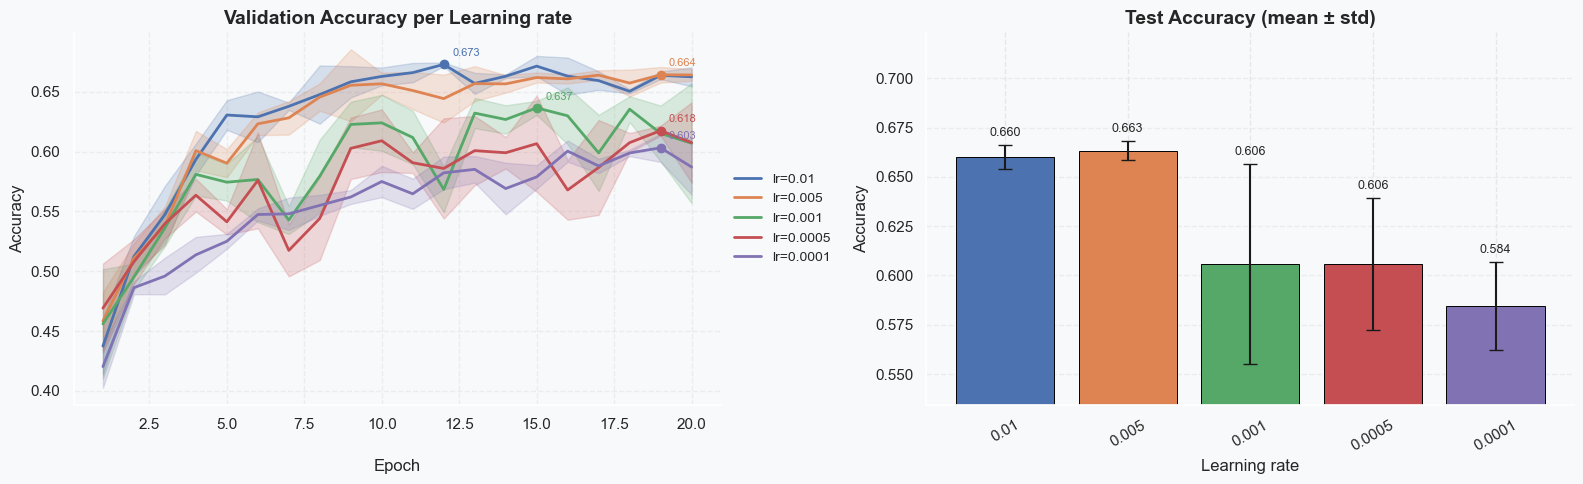

In [200]:
plot_accuracy_comparison(baseline_results, param_name='Learning rate', param_name_short='lr')

In [ ]:
save_results(baseline_results, 'lr_results_baseline')